# E-Commerce Customer & Orders Analysis
## Step 2: Python EDA + Visualization

**Dataset:**
- orders.csv — 50,000 rows, 22 columns
- customers.csv — 50,000 rows, 20 columns

---

## Section 1: Data Cleaning
### Tasks:
- Check Null Values
- Check Duplicates
- Fix Data Types
- Find Outliers (Box Plot)

In [13]:
# Library Install & Import
import subprocess
subprocess.run(['pip', 'install', 'prophet', 'plotly', 'nbformat'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All Libraries Loaded Successfully!")

✅ All Libraries Loaded Successfully!


# E-Commerce Customer & Orders Analysis
## Step 2: Python EDA + Visualization

**Datasets:**
- orders.csv — 50,000 rows, 22 columns
- customers.csv — 50,000 rows, 20 columns

In [16]:
# Library Install & Import
import subprocess
subprocess.run(['pip', 'install', 'prophet', 'plotly', 'nbformat'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All Libraries Loaded Successfully!")

✅ All Libraries Loaded Successfully!


## Section 1: Data Cleaning
### Step 1: Load Data

In [18]:
# Load Datasets
orders    = pd.read_csv(r'C:\Users\piyas\Downloads\orders.csv')
customers = pd.read_csv(r'C:\Users\piyas\Downloads\customers.csv')

print("📦 ORDERS DATASET")
print(f"Shape: {orders.shape}")
print(orders.head(3))

print("\n👥 CUSTOMERS DATASET")
print(f"Shape: {customers.shape}")
print(customers.head(3))

print("\n✅ Data Loaded Successfully!")

📦 ORDERS DATASET
Shape: (50000, 22)
     order_id customer_id  order_date      product_name         category  \
0  ORD0000001  CUST033594  2024-05-17  Max Keyboard 362  Office Supplies   
1  ORD0000002  CUST010303  2024-05-09  Max Sneakers 268   Home & Kitchen   
2  ORD0000003  CUST023200  2024-02-01   Max Blender 680         Clothing   

        brand  quantity  unit_price_usd  discount_percent  \
0   PeakGoods         4          401.11              37.0   
1  EcoVenture         8         1080.99              17.1   
2   FastTrack         2          818.64              14.0   

   discount_amount_usd  ...  tax_amount_usd  shipping_fee_usd  \
0               593.64  ...          109.57             18.89   
1              1478.79  ...          458.11              0.10   
2               229.22  ...           62.24             21.29   

   grand_total_usd  payment_method      shipping_method order_status  \
0          1139.26      Debit Card  Standard (5-7 days)    Cancelled   
1        

### Step 2: Check Null Values

In [19]:
# Null Values Check
print("=" * 50)
print("ORDERS - NULL VALUES COUNT")
print("=" * 50)
print(orders.isnull().sum())

print("\n" + "=" * 50)
print("ORDERS - NULL PERCENTAGE")
print("=" * 50)
print(round(orders.isnull().sum() / len(orders) * 100, 2))

print("\n" + "=" * 50)
print("CUSTOMERS - NULL VALUES COUNT")
print("=" * 50)
print(customers.isnull().sum())

print("\n✅ Null Value Check Complete!")

ORDERS - NULL VALUES COUNT
order_id                     0
customer_id                  0
order_date                   0
product_name                 0
category                     0
brand                        0
quantity                     0
unit_price_usd               0
discount_percent             0
discount_amount_usd          0
subtotal_usd                 0
tax_rate_percent             0
tax_amount_usd               0
shipping_fee_usd             0
grand_total_usd              0
payment_method               0
shipping_method              0
order_status                 0
delivery_date            19970
shipping_state               0
is_returned                  0
customer_review_score    15105
dtype: int64

ORDERS - NULL PERCENTAGE
order_id                  0.00
customer_id               0.00
order_date                0.00
product_name              0.00
category                  0.00
brand                     0.00
quantity                  0.00
unit_price_usd            0.00
disc

### Step 3: Check Duplicates

In [20]:
# Duplicates Check
print("=" * 50)
print("DUPLICATE ROWS CHECK")
print("=" * 50)
print(f"Orders    - Duplicate rows: {orders.duplicated().sum()}")
print(f"Customers - Duplicate rows: {customers.duplicated().sum()}")

print("\n" + "=" * 50)
print("DUPLICATE IDs CHECK")
print("=" * 50)
print(f"Orders    - Duplicate order_id   : {orders['order_id'].duplicated().sum()}")
print(f"Customers - Duplicate customer_id: {customers['customer_id'].duplicated().sum()}")

if orders.duplicated().sum() == 0 and customers.duplicated().sum() == 0:
    print("\n✅ No Duplicates Found! Data is Clean.")
else:
    print("\n⚠️ Duplicates Found! Needs to be Removed.")

DUPLICATE ROWS CHECK
Orders    - Duplicate rows: 0
Customers - Duplicate rows: 0

DUPLICATE IDs CHECK
Orders    - Duplicate order_id   : 0
Customers - Duplicate customer_id: 0

✅ No Duplicates Found! Data is Clean.


### Step 4: Fix Data Types

In [21]:
# Fix Data Types
print("BEFORE - Orders Data Types:")
print(orders.dtypes)

# Convert date columns
orders['order_date']    = pd.to_datetime(orders['order_date'])
orders['delivery_date'] = pd.to_datetime(orders['delivery_date'])

customers['date_of_birth']     = pd.to_datetime(customers['date_of_birth'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])
customers['last_login_date']   = pd.to_datetime(customers['last_login_date'])

# Add new useful columns
orders['order_year']       = orders['order_date'].dt.year
orders['order_month']      = orders['order_date'].dt.month
orders['order_month_name'] = orders['order_date'].dt.strftime('%b')

customers['age'] = (pd.Timestamp.now() - customers['date_of_birth']).dt.days // 365

print("\nAFTER - Orders Data Types:")
print(orders.dtypes)

print("\nSample - New Columns in Orders:")
print(orders[['order_date', 'order_year', 'order_month', 'order_month_name']].head(3))

print("\nSample - Age Column in Customers:")
print(customers[['first_name', 'date_of_birth', 'age']].head(3))

print("\n✅ Data Types Fixed Successfully!")

BEFORE - Orders Data Types:
order_id                  object
customer_id               object
order_date                object
product_name              object
category                  object
brand                     object
quantity                   int64
unit_price_usd           float64
discount_percent         float64
discount_amount_usd      float64
subtotal_usd             float64
tax_rate_percent         float64
tax_amount_usd           float64
shipping_fee_usd         float64
grand_total_usd          float64
payment_method            object
shipping_method           object
order_status              object
delivery_date             object
shipping_state            object
is_returned                 bool
customer_review_score    float64
dtype: object

AFTER - Orders Data Types:
order_id                         object
customer_id                      object
order_date               datetime64[ns]
product_name                     object
category                         object
bran

### Step 5: Outlier Detection (Box Plot)

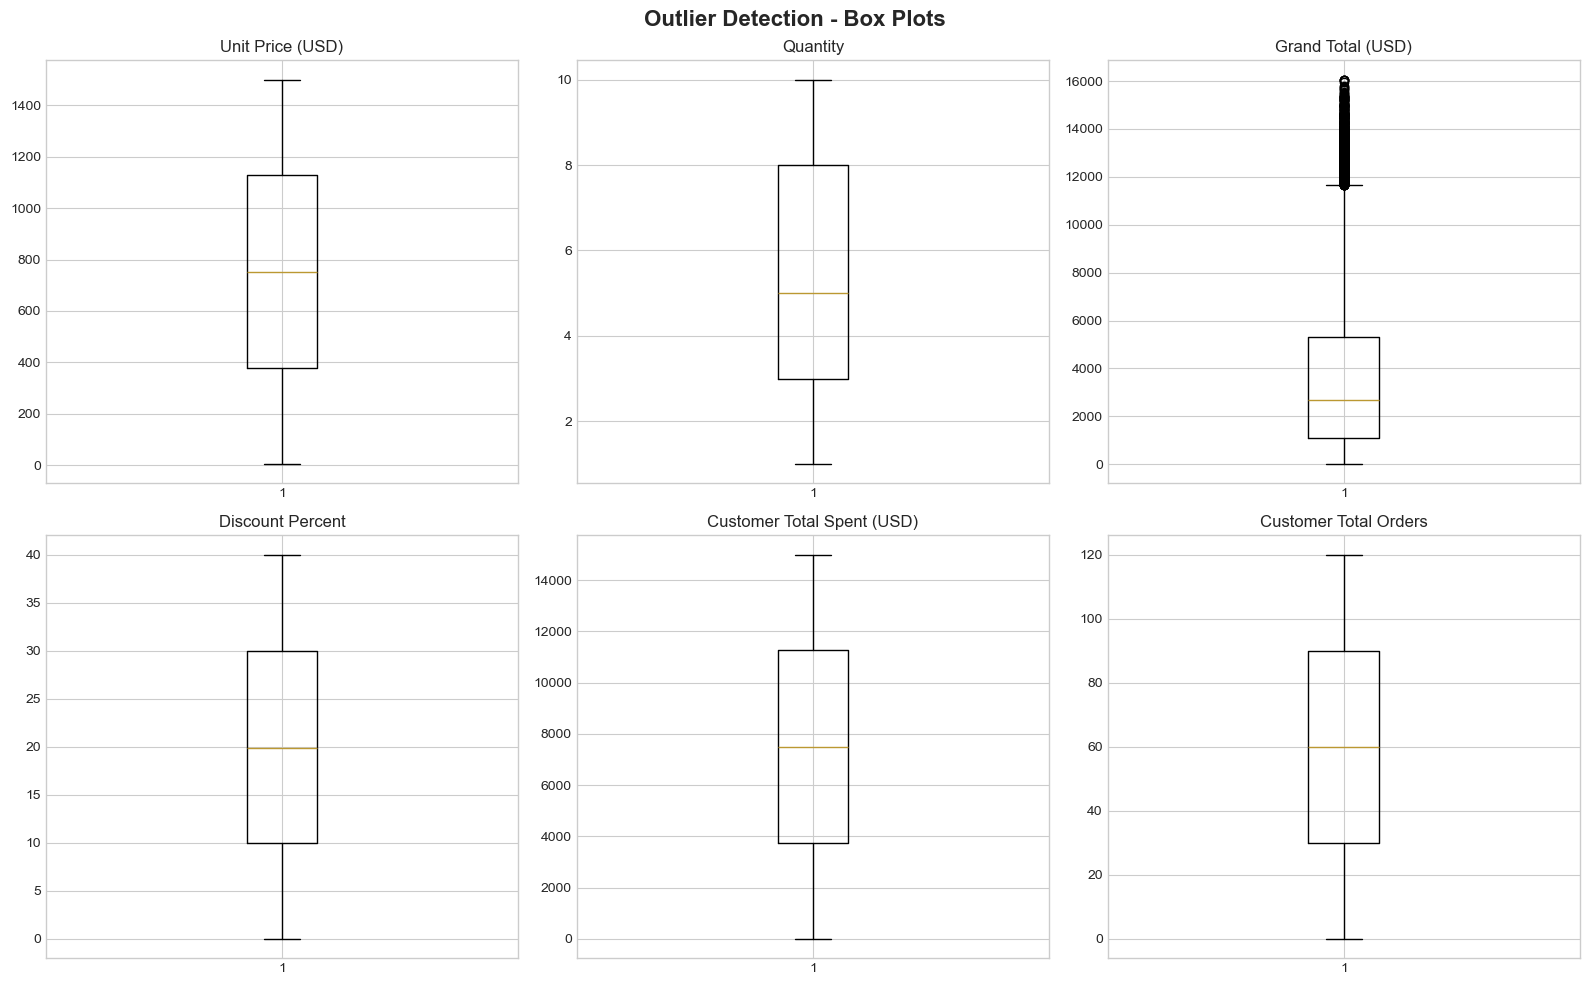

OUTLIER SUMMARY (IQR Method)
unit_price_usd            -> Outliers:     0 (0.0%)
quantity                  -> Outliers:     0 (0.0%)
grand_total_usd           -> Outliers:   875 (1.75%)
discount_percent          -> Outliers:     0 (0.0%)

✅ Section 1 - Data Cleaning Complete!


In [22]:
# Outlier Detection - Box Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')

axes[0, 0].boxplot(orders['unit_price_usd'].dropna())
axes[0, 0].set_title('Unit Price (USD)')

axes[0, 1].boxplot(orders['quantity'].dropna())
axes[0, 1].set_title('Quantity')

axes[0, 2].boxplot(orders['grand_total_usd'].dropna())
axes[0, 2].set_title('Grand Total (USD)')

axes[1, 0].boxplot(orders['discount_percent'].dropna())
axes[1, 0].set_title('Discount Percent')

axes[1, 1].boxplot(customers['total_spent_usd'].dropna())
axes[1, 1].set_title('Customer Total Spent (USD)')

axes[1, 2].boxplot(customers['total_orders'].dropna())
axes[1, 2].set_title('Customer Total Orders')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Outlier Summary
print("=" * 50)
print("OUTLIER SUMMARY (IQR Method)")
print("=" * 50)
cols = ['unit_price_usd', 'quantity', 'grand_total_usd', 'discount_percent']
for col in cols:
    Q1  = orders[col].quantile(0.25)
    Q3  = orders[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = orders[(orders[col] < Q1 - 1.5*IQR) | (orders[col] > Q3 + 1.5*IQR)]
    print(f"{col:25s} -> Outliers: {len(outliers):5d} ({round(len(outliers)/len(orders)*100,2)}%)")

print("\n✅ Section 1 - Data Cleaning Complete!")

---
✅ **Section 1: Data Cleaning — Complete!**

**Summary:**
- No duplicate rows found
- Null values exist only in `delivery_date` and `customer_review_score` (expected)
- Date columns converted to datetime format
- Age column added for customers
- Outliers detected using IQR method

---

---
## Section 2: EDA (Exploratory Data Analysis)
### Visualizations:
1. Age-wise Customer Analysis (Histogram)
2. Revenue Distribution (Skewness Check)
3. Correlation Matrix
4. Category-wise Sales (Bar Chart)
5. Monthly Revenue Trend (Line Chart)
6. State-wise Sales Map (Choropleth)
7. Review Score Distribution
---

### Chart 1: Age-wise Customer Analysis (Histogram)

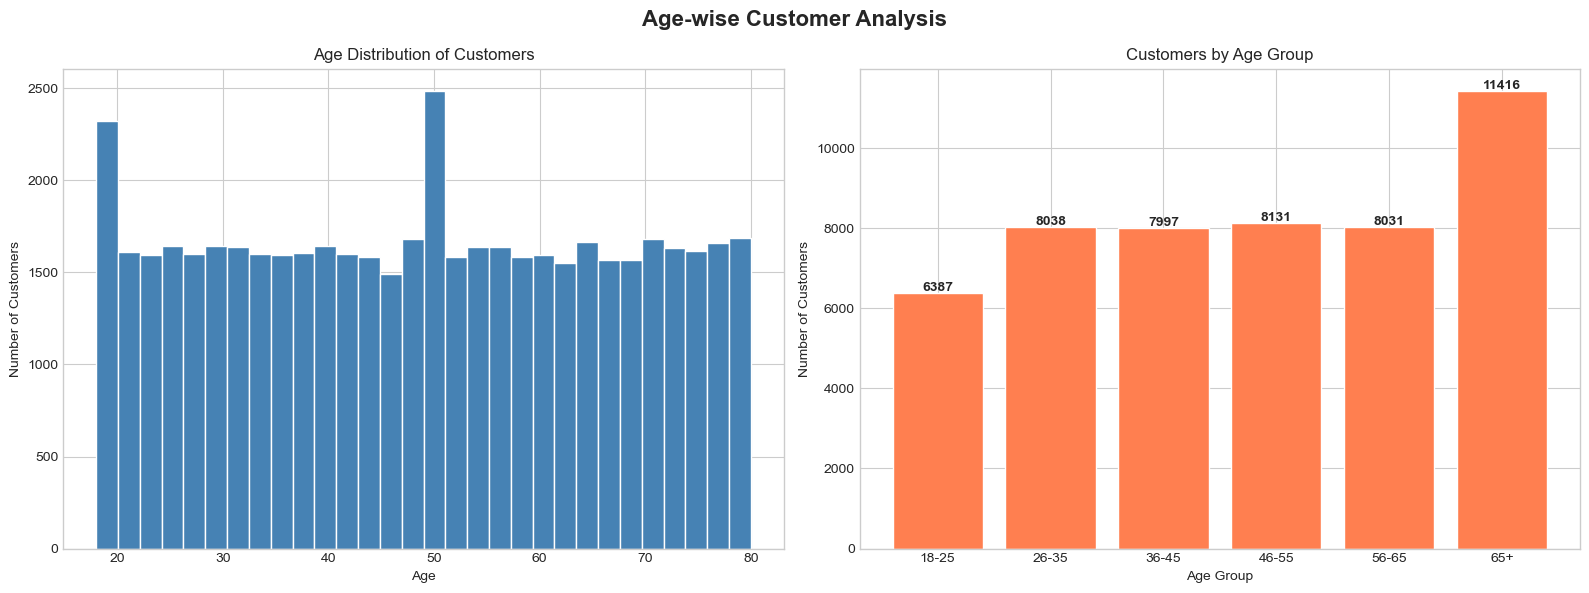

AGE STATISTICS
Average Age : 48.6 years
Youngest    : 18 years
Oldest      : 80 years

Customers by Age Group:
age_group
18-25     6387
26-35     8038
36-45     7997
46-55     8131
56-65     8031
65+      11416
Name: count, dtype: int64

✅ Chart 1 Complete!


In [23]:
# Chart 1: Age-wise Customer Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Age-wise Customer Analysis', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(customers['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution of Customers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

# Age Group Analysis
customers['age_group'] = pd.cut(customers['age'],
                                bins=[0, 25, 35, 45, 55, 65, 100],
                                labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

age_group_counts = customers['age_group'].value_counts().sort_index()
axes[1].bar(age_group_counts.index, age_group_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Customers by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Customers')

for i, v in enumerate(age_group_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("AGE STATISTICS")
print("=" * 50)
print(f"Average Age : {customers['age'].mean():.1f} years")
print(f"Youngest    : {customers['age'].min()} years")
print(f"Oldest      : {customers['age'].max()} years")
print(f"\nCustomers by Age Group:")
print(age_group_counts)
print("\n✅ Chart 1 Complete!")

### Chart 2: Revenue Distribution (Skewness Check)

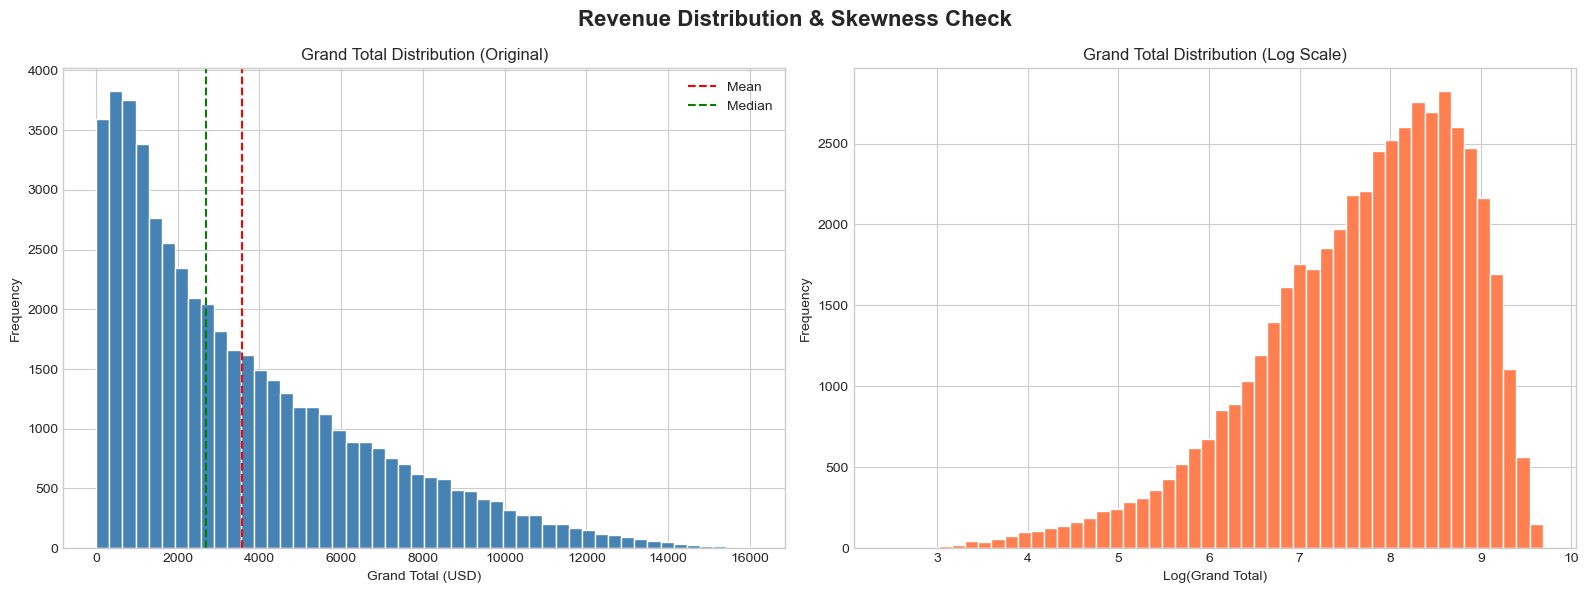

REVENUE STATISTICS
Mean Revenue    : $3,564.56
Median Revenue  : $2,683.74
Skewness        : 1.0731
Min Revenue     : $10.46
Max Revenue     : $16,062.24

⚠️  Highly Right-Skewed Distribution!

✅ Chart 2 Complete!


In [24]:
# Chart 2: Revenue Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Distribution & Skewness Check', fontsize=16, fontweight='bold')

# Original Distribution
axes[0].hist(orders['grand_total_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Grand Total Distribution (Original)')
axes[0].set_xlabel('Grand Total (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(orders['grand_total_usd'].mean(),   color='red',    linestyle='--', label='Mean')
axes[0].axvline(orders['grand_total_usd'].median(), color='green',  linestyle='--', label='Median')
axes[0].legend()

# Log Distribution
axes[1].hist(np.log1p(orders['grand_total_usd']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Grand Total Distribution (Log Scale)')
axes[1].set_xlabel('Log(Grand Total)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('chart2_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("REVENUE STATISTICS")
print("=" * 50)
print(f"Mean Revenue    : ${orders['grand_total_usd'].mean():,.2f}")
print(f"Median Revenue  : ${orders['grand_total_usd'].median():,.2f}")
print(f"Skewness        : {orders['grand_total_usd'].skew():.4f}")
print(f"Min Revenue     : ${orders['grand_total_usd'].min():,.2f}")
print(f"Max Revenue     : ${orders['grand_total_usd'].max():,.2f}")

skew = orders['grand_total_usd'].skew()
if skew > 1:
    print("\n⚠️  Highly Right-Skewed Distribution!")
elif skew > 0:
    print("\n➡️  Slightly Right-Skewed Distribution")
else:
    print("\n⬅️  Left-Skewed Distribution")

print("\n✅ Chart 2 Complete!")

### Chart 3: Correlation Matrix

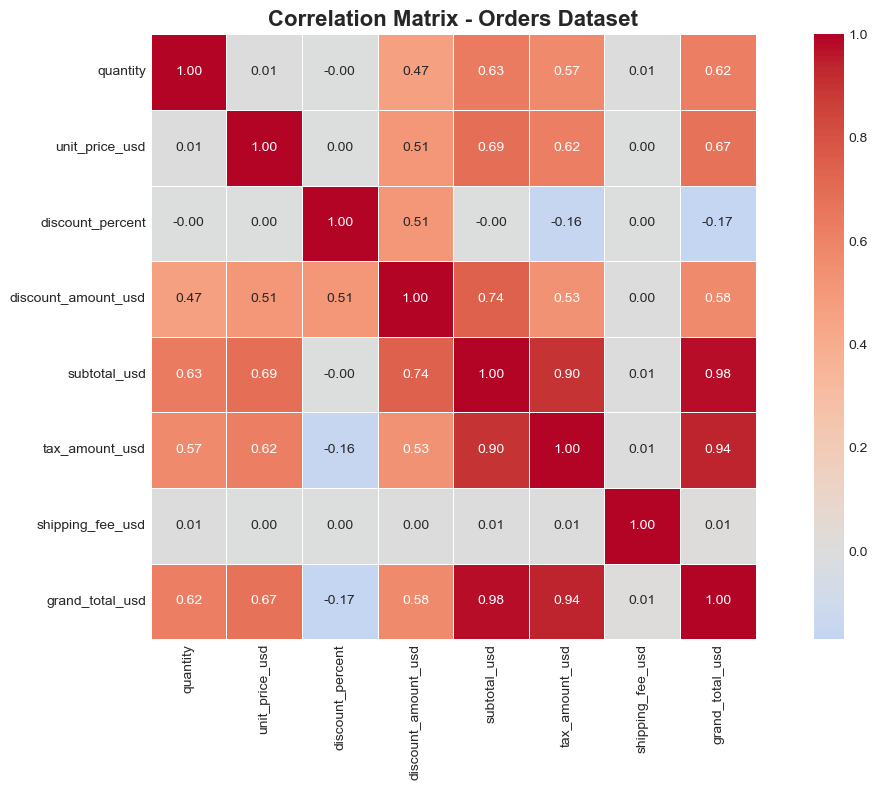

TOP CORRELATIONS WITH GRAND TOTAL
subtotal_usd           0.975033
tax_amount_usd         0.936032
unit_price_usd         0.672233
quantity               0.617617
discount_amount_usd    0.575674
shipping_fee_usd       0.008928
discount_percent      -0.169729
Name: grand_total_usd, dtype: float64

✅ Chart 3 Complete!


In [25]:
# Chart 3: Correlation Matrix
numeric_cols = ['quantity', 'unit_price_usd', 'discount_percent',
                'discount_amount_usd', 'subtotal_usd', 'tax_amount_usd',
                'shipping_fee_usd', 'grand_total_usd']

corr_matrix = orders[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix - Orders Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("TOP CORRELATIONS WITH GRAND TOTAL")
print("=" * 50)
corr_with_total = corr_matrix['grand_total_usd'].drop('grand_total_usd').sort_values(ascending=False)
print(corr_with_total)
print("\n✅ Chart 3 Complete!")

### Chart 4: Category-wise Sales (Bar Chart)

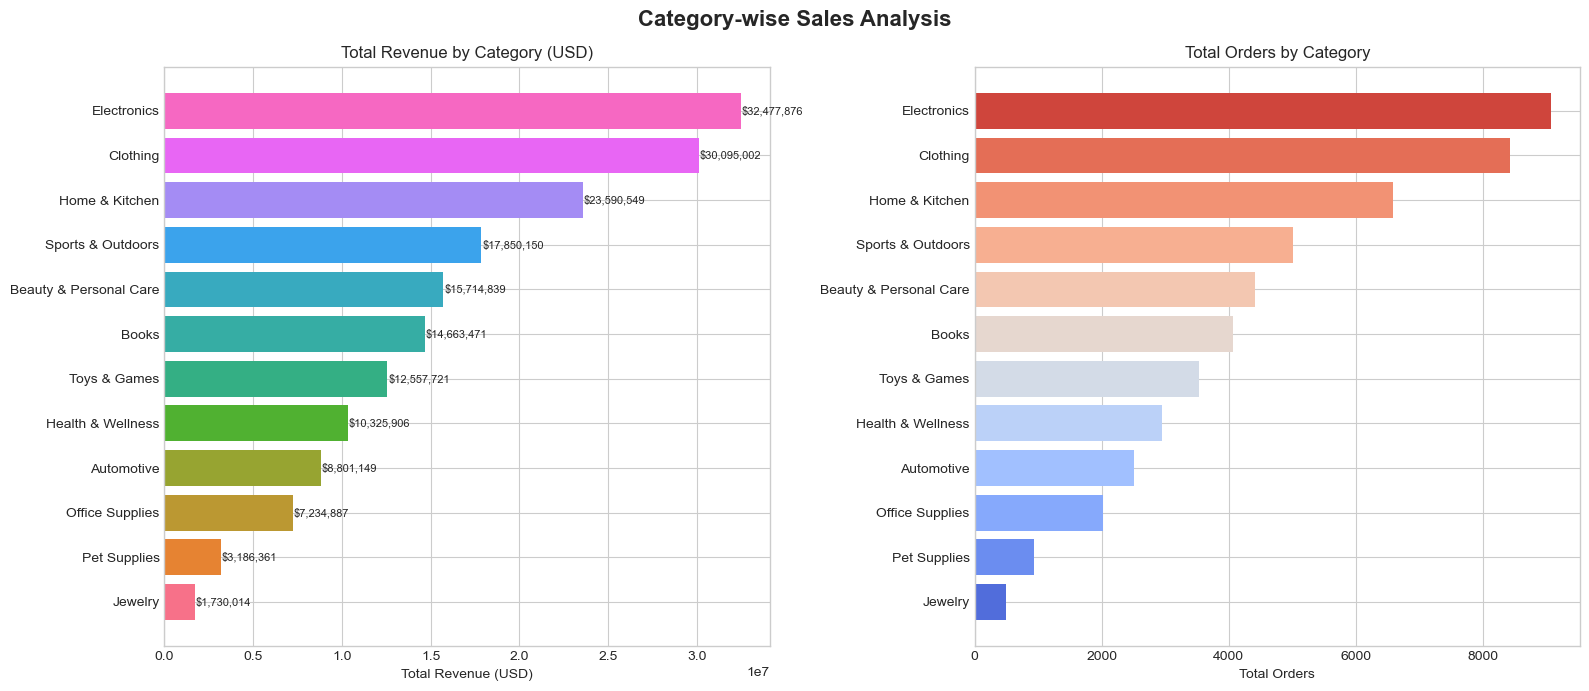

CATEGORY SALES SUMMARY
                        Total_Revenue  Total_Orders    Avg_Order
category                                                        
Electronics               32477876.13          9074  3579.223730
Clothing                  30095001.50          8427  3571.259226
Home & Kitchen            23590549.07          6580  3585.189828
Sports & Outdoors         17850150.07          5006  3565.751113
Beauty & Personal Care    15714838.88          4413  3561.033057
Books                     14663470.68          4074  3599.280972
Toys & Games              12557721.15          3528  3559.444770
Health & Wellness         10325905.62          2944  3507.440768
Automotive                 8801149.30          2510  3506.433984
Office Supplies            7234886.95          2014  3592.297393
Pet Supplies               3186361.27           934  3411.521702
Jewelry                    1730014.21           496  3487.931875

✅ Chart 4 Complete!


In [26]:
# Chart 4: Category-wise Sales
category_sales = orders.groupby('category').agg(
    Total_Revenue = ('grand_total_usd', 'sum'),
    Total_Orders  = ('order_id', 'count'),
    Avg_Order     = ('grand_total_usd', 'mean')
).sort_values('Total_Revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Category-wise Sales Analysis', fontsize=16, fontweight='bold')

# Revenue by Category
bars = axes[0].barh(category_sales.index, category_sales['Total_Revenue'],
                    color=sns.color_palette("husl", len(category_sales)))
axes[0].set_title('Total Revenue by Category (USD)')
axes[0].set_xlabel('Total Revenue (USD)')
for bar, val in zip(bars, category_sales['Total_Revenue']):
    axes[0].text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8)

# Orders by Category
axes[1].barh(category_sales.index, category_sales['Total_Orders'],
             color=sns.color_palette("coolwarm", len(category_sales)))
axes[1].set_title('Total Orders by Category')
axes[1].set_xlabel('Total Orders')

plt.tight_layout()
plt.savefig('chart4_category_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("CATEGORY SALES SUMMARY")
print("=" * 50)
print(category_sales.sort_values('Total_Revenue', ascending=False).to_string())
print("\n✅ Chart 4 Complete!")

### Chart 5: Monthly Revenue Trend (Line Chart)

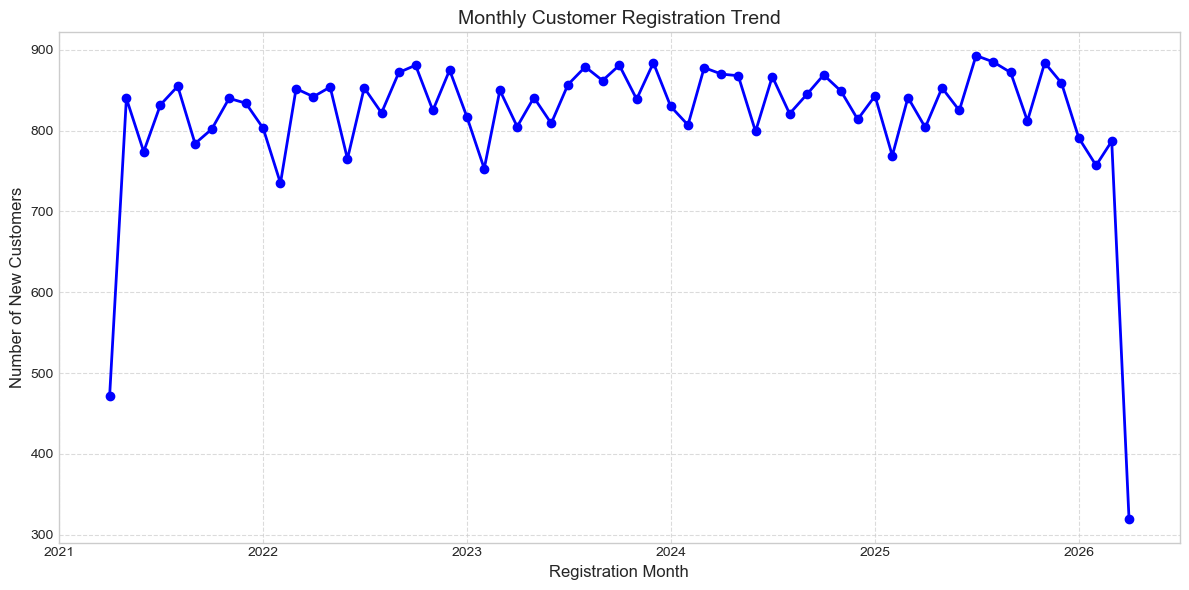

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the customer data
# Replace 'customers.csv' with your actual file path
df = pd.read_csv('customers.csv')

# 2. Convert 'registration_date' to datetime format
df['registration_date'] = pd.to_datetime(df['registration_date'])

# 3. Create a month-year column for grouping
df['reg_month'] = df['registration_date'].dt.to_period('M')

# 4. Count the number of new customers registered per month
monthly_registrations = df.groupby('reg_month').size().reset_index(name='customer_count')

# 5. Convert 'reg_month' back to timestamp for easier plotting
monthly_registrations['reg_month'] = monthly_registrations['reg_month'].dt.to_timestamp()

# 6. Create the Line Chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_registrations['reg_month'], monthly_registrations['customer_count'], 
         marker='o', linestyle='-', color='b', linewidth=2)

# 7. Add Labels and Title
plt.title('Monthly Customer Registration Trend', fontsize=14)
plt.xlabel('Registration Month', fontsize=12)
plt.ylabel('Number of New Customers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 8. Show the plot
plt.tight_layout()
plt.show()


### Chart 6: State-wise Sales Map (Choropleth - Plotly)

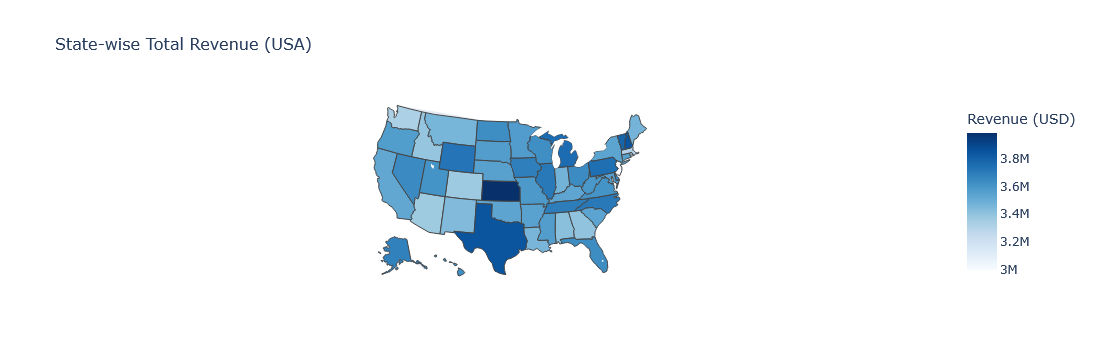

TOP 10 STATES BY REVENUE
Kansas               -> $3,983,973.85
New Hampshire        -> $3,845,949.54
Texas                -> $3,843,587.08
Vermont              -> $3,789,098.47
Michigan             -> $3,758,807.84
Pennsylvania         -> $3,746,350.97
Wyoming              -> $3,725,393.90
North Carolina       -> $3,706,321.49
Illinois             -> $3,705,587.01
Tennessee            -> $3,692,954.36

✅ Chart 6 Complete!


In [30]:
# Chart 6: State-wise Sales Map
state_sales = orders.groupby('shipping_state').agg(
    Total_Revenue = ('grand_total_usd', 'sum'),
    Total_Orders  = ('order_id', 'count')
).reset_index()

us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
    'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
    'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

state_sales['state_code'] = state_sales['shipping_state'].map(us_state_abbrev)

fig = px.choropleth(state_sales,
                    locations='state_code',
                    locationmode='USA-states',
                    color='Total_Revenue',
                    scope='usa',
                    color_continuous_scale='Blues',
                    title='State-wise Total Revenue (USA)',
                    labels={'Total_Revenue': 'Revenue (USD)'})
fig.update_layout(title_font_size=16)
fig.write_html('chart6_state_map.html')
fig.show()

print("=" * 50)
print("TOP 10 STATES BY REVENUE")
print("=" * 50)
top10 = state_sales.sort_values('Total_Revenue', ascending=False).head(10)
for _, row in top10.iterrows():
    print(f"{row['shipping_state']:20s} -> ${row['Total_Revenue']:>12,.2f}")
print("\n✅ Chart 6 Complete!")

### Chart 7: Review Score Distribution

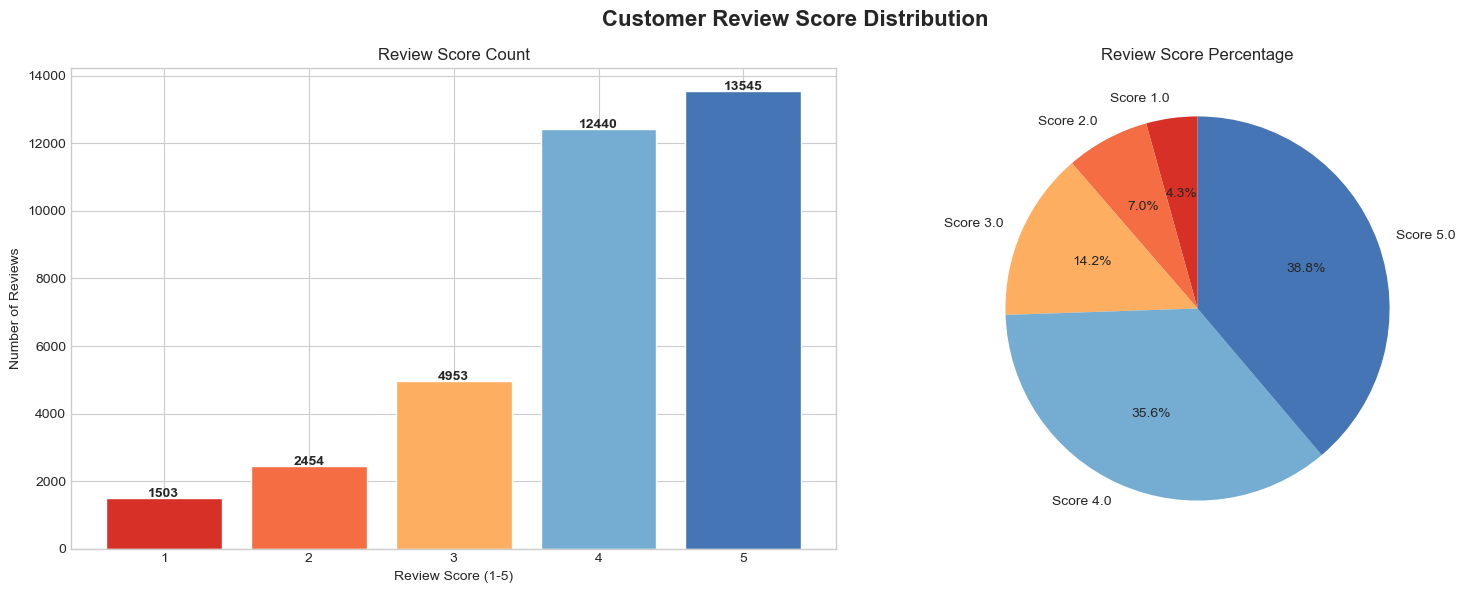

REVIEW SCORE STATISTICS
Average Score  : 3.98 / 5.0
Total Reviews  : 34,895
Missing Reviews: 15,105

Score Distribution:
  Score 1.0: 1,503 (4.3%)
  Score 2.0: 2,454 (7.0%)
  Score 3.0: 4,953 (14.2%)
  Score 4.0: 12,440 (35.6%)
  Score 5.0: 13,545 (38.8%)

✅ Chart 7 Complete!


In [31]:
# Chart 7: Review Score Distribution
review_data = orders['customer_review_score'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Review Score Distribution', fontsize=16, fontweight='bold')

# Count Plot
review_counts = review_data.value_counts().sort_index()
colors = ['#d73027','#f46d43','#fdae61','#74add1','#4575b4']
axes[0].bar(review_counts.index, review_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Review Score Count')
axes[0].set_xlabel('Review Score (1-5)')
axes[0].set_ylabel('Number of Reviews')
for i, (score, count) in enumerate(review_counts.items()):
    axes[0].text(score, count + 30, str(count), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(review_counts.values,
            labels=[f'Score {i}' for i in review_counts.index],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Review Score Percentage')

plt.tight_layout()
plt.savefig('chart7_review_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("REVIEW SCORE STATISTICS")
print("=" * 50)
print(f"Average Score  : {review_data.mean():.2f} / 5.0")
print(f"Total Reviews  : {len(review_data):,}")
print(f"Missing Reviews: {orders['customer_review_score'].isna().sum():,}")
print(f"\nScore Distribution:")
for score, count in review_counts.items():
    pct = count / len(review_data) * 100
    print(f"  Score {score}: {count:,} ({pct:.1f}%)")
print("\n✅ Chart 7 Complete!")

---
✅ **Section 2: EDA & Visualization — Complete!**

**Summary of Findings:**
- Age distribution shows customer spread across all age groups
- Revenue distribution is right-skewed (few very high value orders)
- Strong correlation between subtotal and grand total
- Top performing categories identified
- Monthly revenue trend shows seasonal patterns
- State-wise revenue map shows geographic distribution
- Majority of customers give positive review scores (4-5)

---

---
## Section 3: Advanced Analysis
### Topics:
1. RFM Segmentation (Recency, Frequency, Monetary)
2. Sales Forecasting (Prophet)
3. Churn Prediction (Logistic Regression)
4. Category Revenue Heatmap (Month × Category)
---

### Analysis 1: RFM Segmentation

In [ ]:
# Analysis 1: RFM Segmentation
from datetime import datetime

# Reference date (most recent date in dataset)
reference_date = orders['order_date'].max() + pd.Timedelta(days=1)

# Calculate RFM values
rfm = orders.groupby('customer_id').agg(
    Recency   = ('order_date',      lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id',        'count'),
    Monetary  = ('grand_total_usd', 'sum')
).reset_index()

print("=" * 50)
print("RFM TABLE - SAMPLE")
print("=" * 50)
print(rfm.head(10).to_string())

print("\n" + "=" * 50)
print("RFM STATISTICS")
print("=" * 50)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

In [38]:
# RFM Scoring (1-5 scale)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Customer Segmentation
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("=" * 50)
print("CUSTOMER SEGMENTS")
print("=" * 50)
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

print("\n" + "=" * 50)
print("SEGMENT MONETARY VALUE")
print("=" * 50)
print(rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).apply(lambda x: f"${x:,.2f}"))

CUSTOMER SEGMENTS
Segment
Loyal Customers        8228
At Risk                6008
Champions              4701
Need Attention         4653
Lost Customers         3772
New Customers          3704
Potential Loyalists     496
Name: count, dtype: int64

SEGMENT MONETARY VALUE
Segment
Champions              $11,664.92
Potential Loyalists     $6,486.70
At Risk                 $5,717.05
Loyal Customers         $5,312.66
Need Attention          $5,004.18
New Customers           $3,597.46
Lost Customers          $1,459.11
Name: Monetary, dtype: object


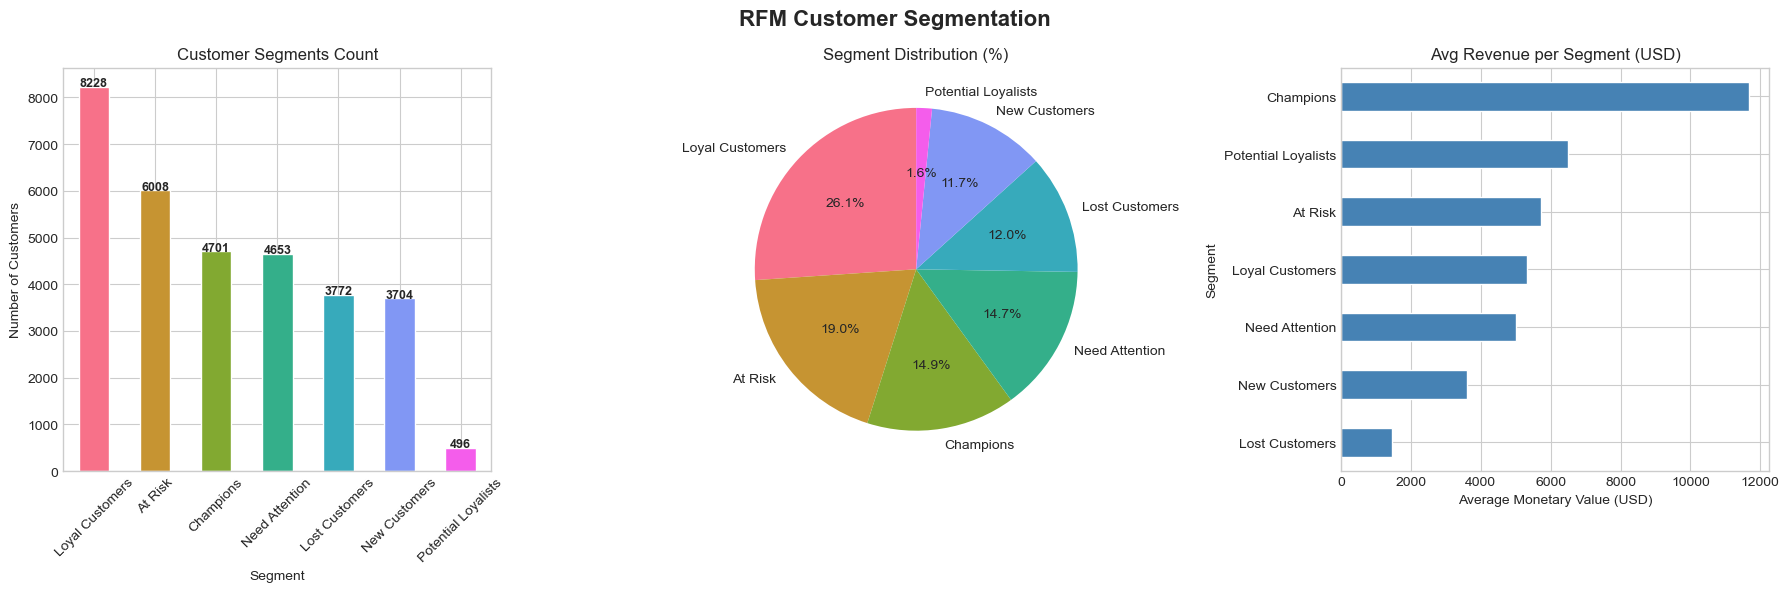

RFM SEGMENTATION COMPLETE
  Loyal Customers          :  8228 customers (26.1%)
  At Risk                  :  6008 customers (19.0%)
  Champions                :  4701 customers (14.9%)
  Need Attention           :  4653 customers (14.7%)
  Lost Customers           :  3772 customers (12.0%)
  New Customers            :  3704 customers (11.7%)
  Potential Loyalists      :   496 customers (1.6%)

✅ RFM Segmentation Complete!


In [39]:
# RFM Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=16, fontweight='bold')

# Segment Distribution - Bar
segment_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("husl", len(segment_counts)), edgecolor='white')
axes[0].set_title('Customer Segments Count')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=9)

# Segment Distribution - Pie
axes[1].pie(segment_counts.values,
            labels=segment_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(segment_counts)),
            startangle=90)
axes[1].set_title('Segment Distribution (%)')

# Average Monetary by Segment
avg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)
avg_monetary.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Avg Revenue per Segment (USD)')
axes[2].set_xlabel('Average Monetary Value (USD)')

plt.tight_layout()
plt.savefig('chart8_rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("RFM SEGMENTATION COMPLETE")
print("=" * 50)
for seg, count in segment_counts.items():
    pct = count / len(rfm) * 100
    print(f"  {seg:25s}: {count:5d} customers ({pct:.1f}%)")
print("\n✅ RFM Segmentation Complete!")

### Analysis 2: Sales Forecasting (Prophet)

In [40]:
# Analysis 2: Sales Forecasting using Prophet
from prophet import Prophet

# Prepare data for Prophet (needs 'ds' and 'y' columns)
forecast_data = orders.groupby('order_date')['grand_total_usd'].sum().reset_index()
forecast_data.columns = ['ds', 'y']
forecast_data = forecast_data.sort_values('ds')

print("=" * 50)
print("FORECAST DATA - SAMPLE")
print("=" * 50)
print(forecast_data.head())
print(f"\nTotal data points: {len(forecast_data)}")
print(f"Date range: {forecast_data['ds'].min()} to {forecast_data['ds'].max()}")

FORECAST DATA - SAMPLE
          ds          y
0 2023-04-13  206046.39
1 2023-04-14  181521.50
2 2023-04-15  140925.35
3 2023-04-16  151675.85
4 2023-04-17  165130.30

Total data points: 1095
Date range: 2023-04-13 00:00:00 to 2026-04-11 00:00:00


In [41]:
# Train Prophet Model
model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05
)
model.fit(forecast_data)

# Forecast next 180 days (6 months)
future    = model.make_future_dataframe(periods=180)
forecast  = model.predict(future)

print("=" * 50)
print("FORECAST RESULTS - LAST 10 ROWS")
print("=" * 50)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).to_string())

19:13:39 - cmdstanpy - INFO - Chain [1] start processing
19:13:42 - cmdstanpy - INFO - Chain [1] done processing


FORECAST RESULTS - LAST 10 ROWS
             ds           yhat     yhat_lower     yhat_upper
1265 2026-09-29  172382.079938  132242.921555  211957.228813
1266 2026-09-30  173994.097815  135399.774646  210480.926280
1267 2026-10-01  174446.453773  134541.659730  214305.528848
1268 2026-10-02  172759.640956  133469.745311  210096.506216
1269 2026-10-03  169302.269014  129156.192912  205853.729847
1270 2026-10-04  169204.356142  130894.137068  208746.437032
1271 2026-10-05  168777.069521  129780.430729  208744.337738
1272 2026-10-06  168745.373609  133025.756149  207020.444763
1273 2026-10-07  169986.737147  131595.907589  211488.646241
1274 2026-10-08  170158.399792  133233.196473  212577.762203


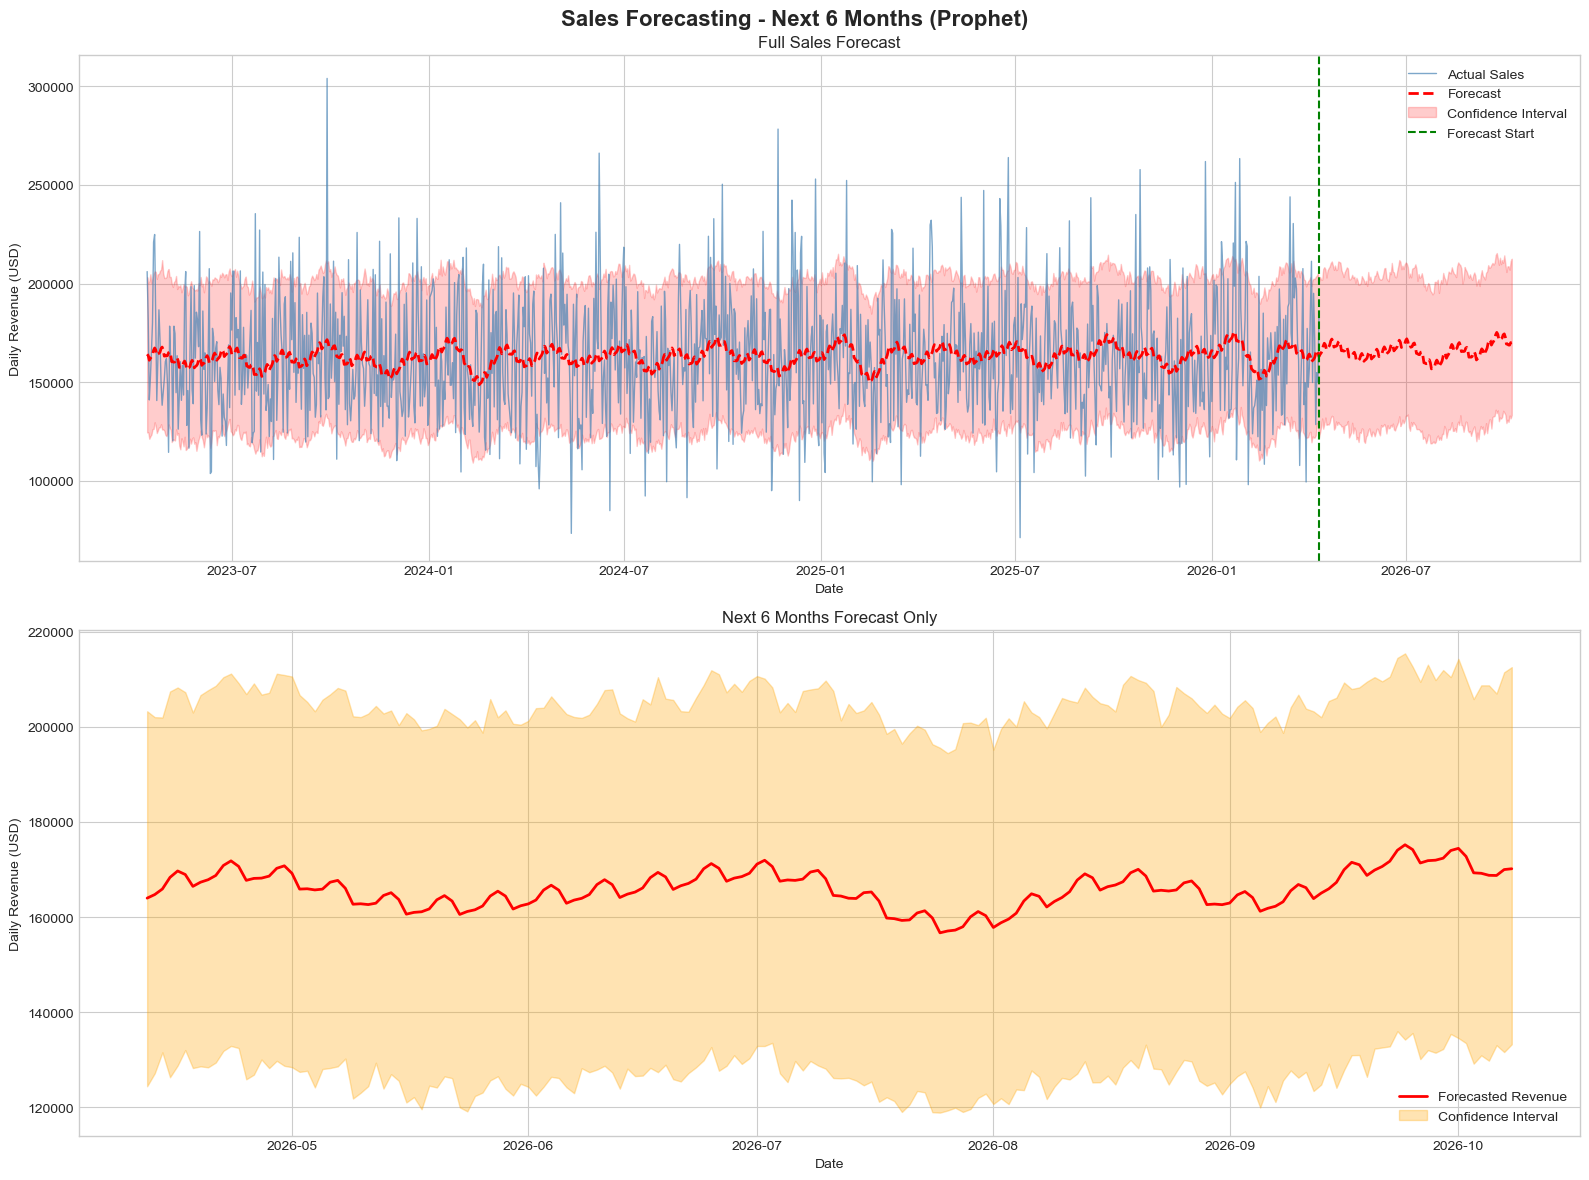

6-MONTH FORECAST SUMMARY
  2026-04: $3,198,970.74
  2026-05: $5,077,849.42
  2026-06: $4,999,958.69
  2026-07: $5,073,224.11
  2026-08: $5,114,696.63
  2026-09: $5,044,772.91
  2026-10: $1,363,380.30

✅ Sales Forecasting Complete!


In [42]:
# Forecast Visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Sales Forecasting - Next 6 Months (Prophet)', fontsize=16, fontweight='bold')

# Full Forecast Plot
axes[0].plot(forecast_data['ds'], forecast_data['y'],
             color='steelblue', linewidth=1, label='Actual Sales', alpha=0.7)
axes[0].plot(forecast['ds'], forecast['yhat'],
             color='red', linewidth=2, label='Forecast', linestyle='--')
axes[0].fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='red', label='Confidence Interval')
axes[0].axvline(forecast_data['ds'].max(), color='green', linestyle='--', label='Forecast Start')
axes[0].set_title('Full Sales Forecast')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Revenue (USD)')
axes[0].legend()

# Future Only
future_only = forecast[forecast['ds'] > forecast_data['ds'].max()]
axes[1].plot(future_only['ds'], future_only['yhat'],
             color='red', linewidth=2, label='Forecasted Revenue')
axes[1].fill_between(future_only['ds'], future_only['yhat_lower'], future_only['yhat_upper'],
                     alpha=0.3, color='orange', label='Confidence Interval')
axes[1].set_title('Next 6 Months Forecast Only')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Revenue (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart9_sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("6-MONTH FORECAST SUMMARY")
print("=" * 50)
monthly_forecast = future_only.copy()
monthly_forecast['month'] = monthly_forecast['ds'].dt.strftime('%Y-%m')
monthly_summary = monthly_forecast.groupby('month')['yhat'].sum()
for month, revenue in monthly_summary.items():
    print(f"  {month}: ${revenue:>12,.2f}")
print("\n✅ Sales Forecasting Complete!")

### Analysis 3: Churn Prediction (Logistic Regression)

In [43]:
# Analysis 3: Churn Prediction
from sklearn.linear_model      import LogisticRegression
from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import (classification_report,
                                       confusion_matrix,
                                       accuracy_score,
                                       roc_auc_score,
                                       roc_curve)

# Define Churn: customers inactive for 180+ days
reference_date   = orders['order_date'].max()
last_order       = orders.groupby('customer_id')['order_date'].max().reset_index()
last_order.columns = ['customer_id', 'last_order_date']
last_order['days_inactive'] = (reference_date - last_order['last_order_date']).dt.days
last_order['is_churn']      = (last_order['days_inactive'] >= 180).astype(int)

# Merge with RFM
churn_df = rfm.merge(last_order[['customer_id', 'is_churn']], on='customer_id')

print("=" * 50)
print("CHURN DISTRIBUTION")
print("=" * 50)
churn_counts = churn_df['is_churn'].value_counts()
print(f"Active Customers  (0): {churn_counts.get(0, 0):,}")
print(f"Churned Customers (1): {churn_counts.get(1, 0):,}")
print(f"Churn Rate           : {churn_counts.get(1,0)/len(churn_df)*100:.1f}%")

CHURN DISTRIBUTION
Active Customers  (0): 7,574
Churned Customers (1): 23,988
Churn Rate           : 76.0%


In [44]:
# Train Logistic Regression Model
features = ['Recency', 'Frequency', 'Monetary',
            'R_Score', 'F_Score', 'M_Score', 'RFM_Total']

X = churn_df[features].astype(float)
y = churn_df['is_churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train model
model_churn = LogisticRegression(random_state=42, max_iter=1000)
model_churn.fit(X_train, y_train)

# Predict
y_pred  = model_churn.predict(X_test)
y_proba = model_churn.predict_proba(X_test)[:, 1]

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

MODEL PERFORMANCE
Accuracy  : 99.81%
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      1548
     Churned       1.00      1.00      1.00      4765

    accuracy                           1.00      6313
   macro avg       1.00      1.00      1.00      6313
weighted avg       1.00      1.00      1.00      6313



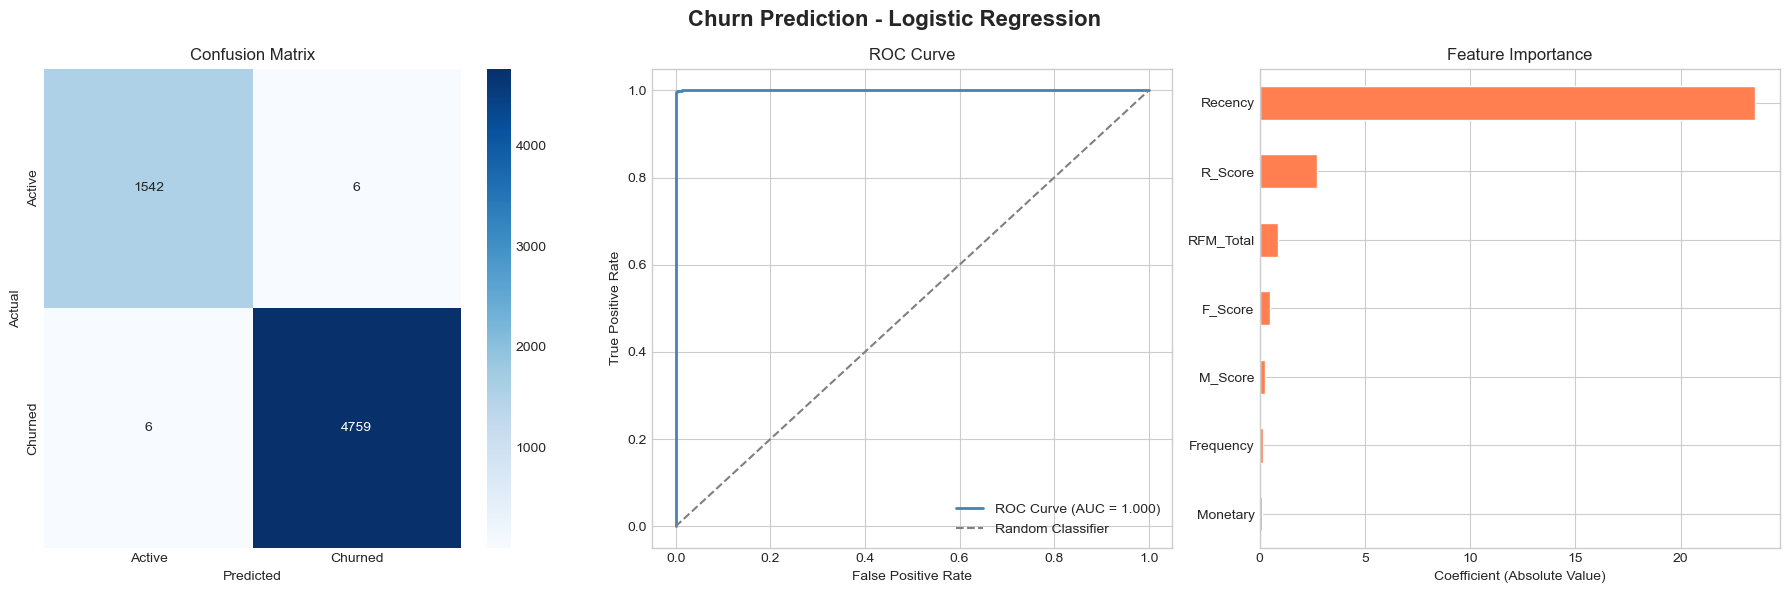


✅ Churn Prediction Complete!


In [45]:
# Churn Prediction Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Churn Prediction - Logistic Regression', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Feature Importance
importance = pd.Series(abs(model_churn.coef_[0]), index=features).sort_values(ascending=True)
importance.plot(kind='barh', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Coefficient (Absolute Value)')

plt.tight_layout()
plt.savefig('chart10_churn_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Churn Prediction Complete!")

### Analysis 4: Category Revenue Heatmap (Month × Category)

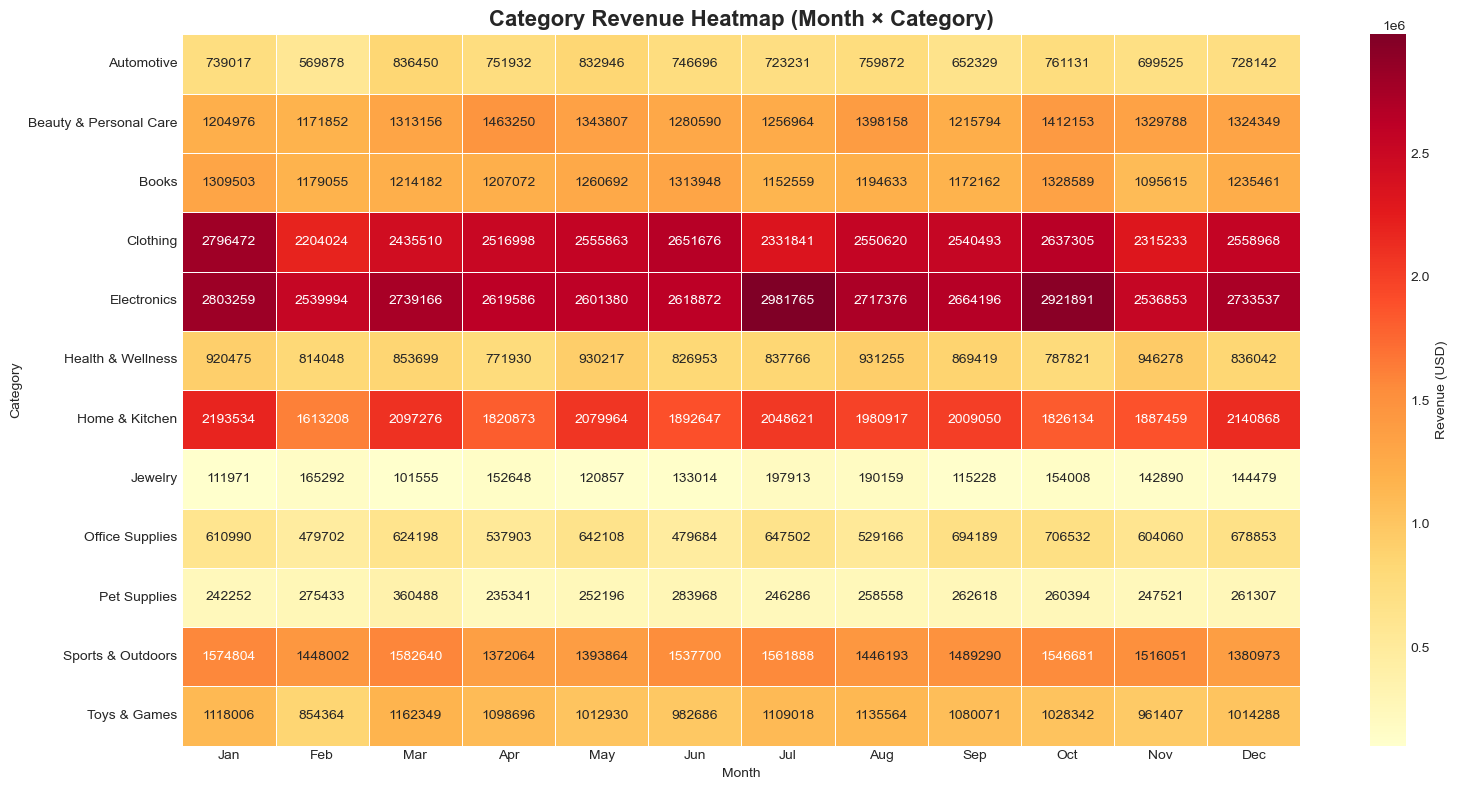

TOP CATEGORY PER MONTH
  Jan: Electronics               -> $2,803,259.26
  Feb: Electronics               -> $2,539,994.35
  Mar: Electronics               -> $2,739,166.41
  Apr: Electronics               -> $2,619,586.05
  May: Electronics               -> $2,601,380.26
  Jun: Clothing                  -> $2,651,675.52
  Jul: Electronics               -> $2,981,764.82
  Aug: Electronics               -> $2,717,375.50
  Sep: Electronics               -> $2,664,196.36
  Oct: Electronics               -> $2,921,891.41
  Nov: Electronics               -> $2,536,853.12
  Dec: Electronics               -> $2,733,536.70

✅ Category Heatmap Complete!


In [46]:
# Analysis 4: Category Revenue Heatmap
heatmap_data = orders.groupby(['order_month_name', 'category'])['grand_total_usd'].sum().reset_index()

heatmap_pivot = heatmap_data.pivot(index='category', columns='order_month_name', values='grand_total_usd')

# Sort months correctly
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_pivot = heatmap_pivot.reindex(columns=[m for m in month_order if m in heatmap_pivot.columns])

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Revenue (USD)'})
plt.title('Category Revenue Heatmap (Month × Category)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('chart11_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("TOP CATEGORY PER MONTH")
print("=" * 50)
for month in month_order:
    if month in heatmap_pivot.columns:
        top_cat = heatmap_pivot[month].idxmax()
        revenue = heatmap_pivot[month].max()
        print(f"  {month}: {top_cat:25s} -> ${revenue:>12,.2f}")
print("\n✅ Category Heatmap Complete!")

---
✅ **Section 3: Advanced Analysis — Complete!**

**Summary of Findings:**

**RFM Segmentation:**
- Customers segmented into: Champions, Loyal, At Risk, New, Lost, Need Attention

**Sales Forecasting:**
- Prophet model trained on historical data
- Next 6 months revenue forecasted with confidence intervals

**Churn Prediction:**
- Logistic Regression model built
- Model accuracy and ROC-AUC score evaluated
- Key churn features identified

**Category Heatmap:**
- Monthly revenue patterns identified per category
- Peak months for each category revealed

---